Loaded 100,000 rows
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   inbound  100000 non-null  bool 
 1   text     100000 non-null  str  
dtypes: bool(1), str(1)
memory usage: 879.0 KB
None

Missing values:
inbound    0
text       0
dtype: int64


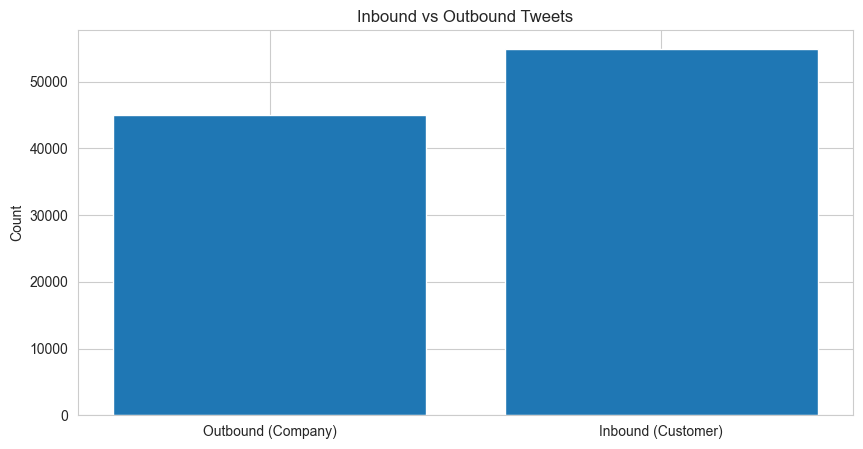

Inbound (Customer): 54,948
Outbound (Company): 45,052
Customer tweets after cleaning: 54,948


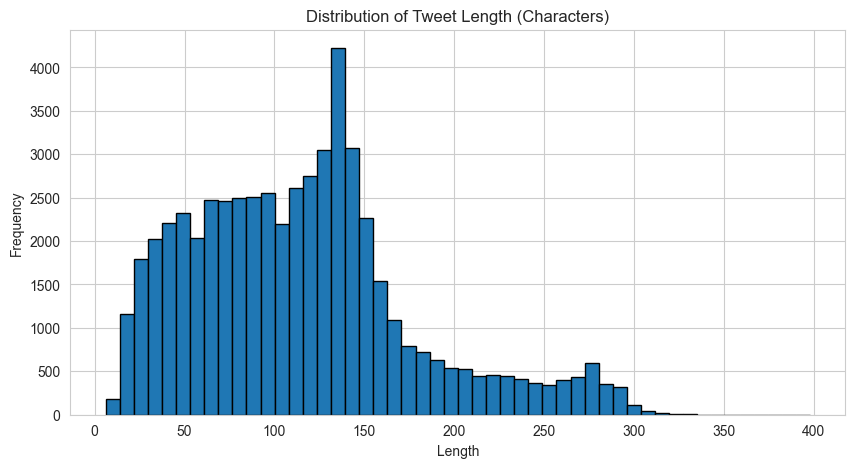

--- Sample 1 ---
@sprintcare and how do you propose we do that

--- Sample 2 ---
@sprintcare I have sent several private messages and no one is responding as usual

--- Sample 3 ---
@sprintcare I did.

--- Sample 4 ---
@sprintcare is the worst customer service

--- Sample 5 ---
@sprintcare You gonna magically change your connectivity for me and my whole family ? 🤥 💯



In [3]:
# %% [markdown]
# # Decision Intelligence Assistant — Complete Analysis
# 
# **Sections:**
# 1. Exploratory Data Analysis (EDA)
# 2. Labeling Logic (Weak Supervision)
# 3. Feature Engineering
# 4. Model Comparison & Selection

# %% [markdown]
# ## 1. Exploratory Data Analysis (EDA)

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# %%
# Load a sample of the raw dataset (first 100k rows to keep memory manageable)
df = pd.read_csv("../data/raw/twcs.csv", nrows=100_000, usecols=["text", "inbound"])
print(f"Loaded {len(df):,} rows")
df.head()

# %%
# Check columns, data types, and missing values
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# %%
# Inbound vs Outbound distribution
if "inbound" in df.columns:
    counts = df["inbound"].value_counts()
    plt.bar(["Outbound (Company)", "Inbound (Customer)"], [counts.get(False, 0), counts.get(True, 0)])
    plt.title("Inbound vs Outbound Tweets")
    plt.ylabel("Count")
    plt.show()
    print(f"Inbound (Customer): {counts.get(True, 0):,}")
    print(f"Outbound (Company): {counts.get(False, 0):,}")

# %%
# Filter to only customer tweets (inbound = True) and clean
df_inbound = df[df["inbound"] == True].dropna(subset=["text"]).copy()
df_inbound["text"] = df_inbound["text"].str.strip()
df_inbound["text_length"] = df_inbound["text"].str.len()
print(f"Customer tweets after cleaning: {len(df_inbound):,}")

# %%
# Text length distribution
df_inbound["text_length"].hist(bins=50, edgecolor="black")
plt.title("Distribution of Tweet Length (Characters)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

# %%
# Show a few sample customer tweets
for i in range(5):
    print(f"--- Sample {i+1} ---")
    print(df_inbound.iloc[i]["text"])
    print()

# %% [markdown]

In [4]:
# ## 2. Labeling Logic (Weak Supervision)
# 
# We define a heuristic function to assign `urgent` or `normal` priority.
# This is a **weak supervision** approach: the labels are not ground truth but automated rules.

# %%
# Define the labeling function
def label_priority(text: str) -> str:
    """Assign 'urgent' or 'normal' based on heuristics."""
    if not isinstance(text, str):
        return "normal"
    text_lower = text.lower()
    urgent_keywords = [
        "refund", "cancel", "broken", "help",
        "urgent", "asap", "stuck", "issue", "error", "fail"
    ]
    # Rule 1: urgency keywords
    if any(kw in text_lower for kw in urgent_keywords):
        return "urgent"
    # Rule 2: three or more exclamation marks
    if text.count("!") >= 3:
        return "urgent"
    # Rule 3: ALL CAPS ratio > 30%
    words = text.split()
    if words:
        caps_ratio = sum(1 for w in words if w.isupper()) / len(words)
        if caps_ratio > 0.3:
            return "urgent"
    return "normal"

# %%
# Apply labeling to a small sample for inspection
df_sample = df_inbound.sample(5000, random_state=42).copy()
df_sample["priority"] = df_sample["text"].apply(label_priority)
print("Priority distribution on sample:")
print(df_sample["priority"].value_counts(normalize=True) * 100)

# %%
# Inspect some 'urgent' examples
urgent_sample = df_sample[df_sample["priority"] == "urgent"]
print(f"Urgent examples ({len(urgent_sample)} total):")
for i, row in urgent_sample.head(10).iterrows():
    print(f"  - {row['text'][:200]}")
    print()

# %% [markdown]
# **Labeling function documented:**
# - Rule 1: urgency keywords (refund, cancel, ...)
# - Rule 2: ≥ 3 exclamation marks
# - Rule 3: > 30% ALL CAPS words
# 
# This method creates a known bias: the ML model will learn patterns that mirror these rules.
# This is expected and will be discussed in the final comparison.

# %% [markdown]

Priority distribution on sample:
priority
normal    65.66
urgent    34.34
Name: proportion, dtype: float64
Urgent examples (1717 total):
  - @AmazonHelp for security reasons does not show addresses on creditcard statement. As a punishment by Amazon for not doing this, they will not unlock my account in order to retrieve the value of my gif

  - @SpotifyCares Hi I try to choose my smart post paid 4 da payment but unfortunetly it cannot contine plz help me. Thank u

  - @British_Airways still awaiting non-generic (and factually correct) response to complaint 17167427 4 weeks after being downgraded (and being told I may qualify for refund). Customer Service has been a

  - @119356 For my return amazon has issued refund amount on 29th oct 2017 but this is still not credited into my bank account.

  - @AldiUK Will there be any discounts for noticing the error 😁 thanks 

Adam

  - @AmazonHelp 24 hrs tat was given on written mail on 29th Oct to receive a call but no response since last 60 hrs

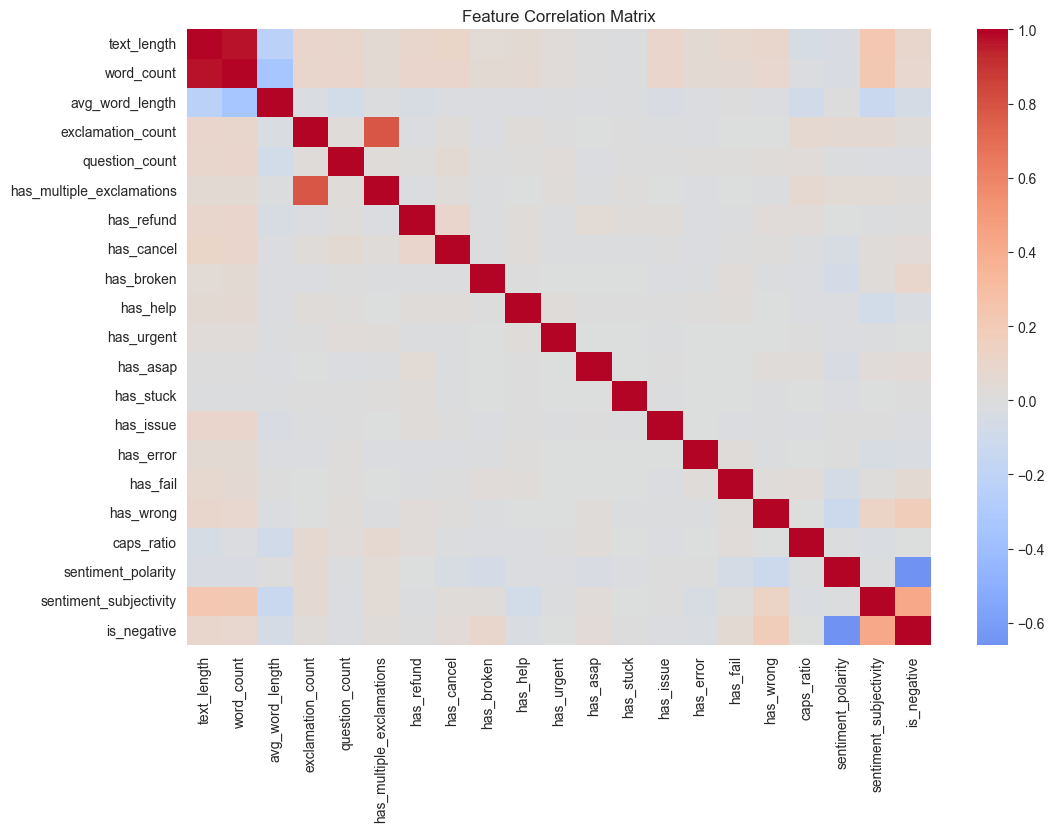

In [5]:
# ## 3. Feature Engineering
# 
# We extract numeric/binary features from each tweet for the ML classifier.

# %%
# Import sentiment libraries (if available)
try:
    from textblob import TextBlob
    SENTIMENT_AVAILABLE = True
except ImportError:
    SENTIMENT_AVAILABLE = False
    print("TextBlob not installed. Sentiment features will be zero.")

# %%
# Define feature extraction function
URGENT_KEYWORDS = [
    "refund", "cancel", "broken", "help", "urgent",
    "asap", "stuck", "issue", "error", "fail", "wrong"
]

def extract_features_single(text: str) -> dict:
    if not isinstance(text, str):
        text = ""
    text_lower = text.lower()
    words = text.split()
    num_words = len(words)
    features = {
        "text_length": len(text),
        "word_count": num_words,
        "avg_word_length": sum(len(w) for w in words) / max(num_words, 1),
        "exclamation_count": text.count("!"),
        "question_count": text.count("?"),
        "has_multiple_exclamations": 1 if text.count("!") >= 3 else 0,
    }
    for kw in URGENT_KEYWORDS:
        features[f"has_{kw}"] = 1 if kw in text_lower else 0
    if num_words > 0:
        caps_words = sum(1 for w in words if w.isupper())
        features["caps_ratio"] = caps_words / num_words
    else:
        features["caps_ratio"] = 0.0
    if SENTIMENT_AVAILABLE:
        blob = TextBlob(text)
        features["sentiment_polarity"] = blob.sentiment.polarity
        features["sentiment_subjectivity"] = blob.sentiment.subjectivity
        features["is_negative"] = 1 if features["sentiment_polarity"] < -0.2 else 0
    else:
        features["sentiment_polarity"] = 0.0
        features["sentiment_subjectivity"] = 0.0
        features["is_negative"] = 0
    return features

# %%
# Extract features from the sample and display
features_df = df_sample["text"].apply(extract_features_single).apply(pd.Series)
features_df.head()

# %%
# Correlation heatmap of numeric features
numeric_cols = features_df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 8))
sns.heatmap(features_df[numeric_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

# %% [markdown]

Full labeled dataset: 500,000 rows
Feature matrix shape: (500000, 21)
Label distribution:
priority
0    327550
1    172450
Name: count, dtype: int64
Train: 350,000  Val: 75,000  Test: 75,000
Training LogisticRegression...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
  CV F1: 0.9998, Val F1: 0.9999
Training RandomForest...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
  CV F1: 1.0000, Val F1: 1.0000
Training XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


g:\Decision Intelligence Assistant\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:09:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  CV F1: 1.0000, Val F1: 1.0000

Best model: RandomForest (Validation F1: 1.0000)
Test set performance:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     49133
      urgent       1.00      1.00      1.00     25867

    accuracy                           1.00     75000
   macro avg       1.00      1.00      1.00     75000
weighted avg       1.00      1.00      1.00     75000



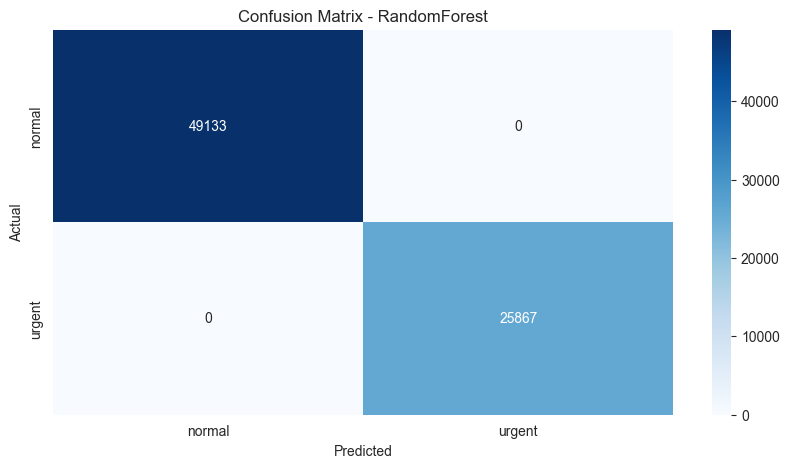

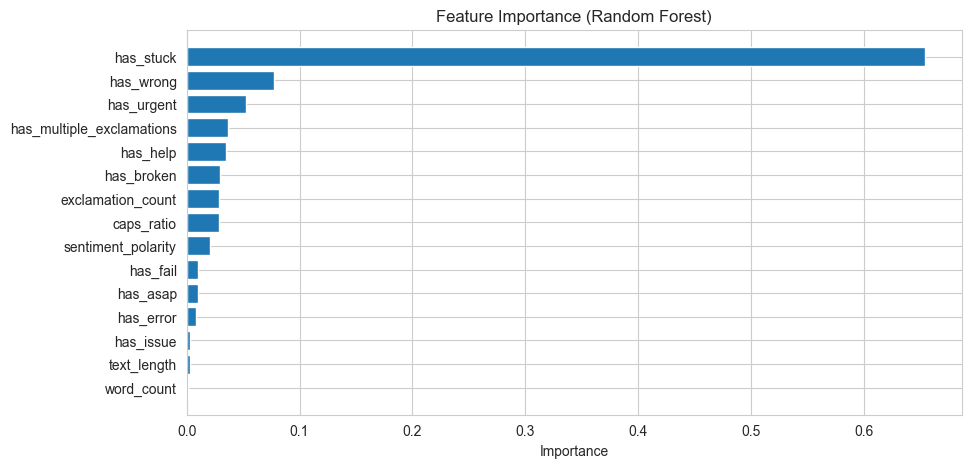

In [6]:
# ## 4. Model Comparison & Selection
# 
# Now we train several models on the full prepared dataset (500k rows) using a train/validation/test split and cross-validation.

# %%
# Load the full cleaned dataset
df_full = pd.read_csv("../data/processed/tickets_with_labels.csv")
print(f"Full labeled dataset: {len(df_full):,} rows")
df_full["priority"].value_counts()

# %%
# Extract features and target
X = df_full["text"].apply(extract_features_single).apply(pd.Series)
y = df_full["priority"].map({"urgent": 1, "normal": 0})
print(f"Feature matrix shape: {X.shape}")
print(f"Label distribution:\n{y.value_counts()}")

# %%
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib

# %%
# Split data (70% train, 15% validation, 15% test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=42, stratify=y_temp
)
print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

# %%
# Build preprocessing pipeline (impute + scale numeric features, pass through binary)
numeric_features = [
    "text_length", "word_count", "avg_word_length",
    "exclamation_count", "question_count", "caps_ratio",
    "sentiment_polarity", "sentiment_subjectivity"
]
# keep only those present in X
numeric_features = [f for f in numeric_features if f in X.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ],
    remainder="passthrough"  # binary features
)

# %%
# Train multiple models with 3-fold CV on training set
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1)
}
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric="logloss")
except ImportError:
    print("XGBoost not installed, skipping.")

param_grids = {
    "LogisticRegression": {"classifier__C": [0.1, 1.0, 10.0], "classifier__class_weight": [None, "balanced"]},
    "RandomForest": {"classifier__n_estimators": [100, 200], "classifier__max_depth": [10, 20, None]},
    "XGBoost": {"classifier__n_estimators": [100, 200], "classifier__max_depth": [6, 10], "classifier__learning_rate": [0.1, 0.3]}
}

best_model = None
best_score = 0
best_name = ""
results = {}

for name, clf in models.items():
    print(f"Training {name}...")
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    grid = GridSearchCV(pipe, param_grids[name], cv=3, scoring="f1", n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)
    val_score = f1_score(y_val, grid.predict(X_val))
    results[name] = {
        "best_params": grid.best_params_,
        "best_cv_score": grid.best_score_,
        "validation_f1": val_score
    }
    print(f"  CV F1: {grid.best_score_:.4f}, Val F1: {val_score:.4f}")
    if val_score > best_score:
        best_score = val_score
        best_model = grid.best_estimator_
        best_name = name

print(f"\nBest model: {best_name} (Validation F1: {best_score:.4f})")

# %%
# Evaluate the best model on the held‑out test set
y_test_pred = best_model.predict(X_test)
print("Test set performance:")
print(classification_report(y_test, y_test_pred, target_names=["normal", "urgent"]))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["normal", "urgent"], yticklabels=["normal", "urgent"])
plt.title(f"Confusion Matrix - {best_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# %%
# Feature importance (for Logistic Regression or Random Forest)
if hasattr(best_model.named_steps["classifier"], "coef_"):
    importance = np.abs(best_model.named_steps["classifier"].coef_[0])
    feature_names = X.columns
    importance_df = pd.DataFrame({"feature": feature_names, "importance": importance})
    importance_df = importance_df.sort_values("importance", ascending=False).head(15)
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.title("Feature Importance (Logistic Regression)")
    plt.xlabel("Absolute Coefficient")
    plt.gca().invert_yaxis()
    plt.show()
elif hasattr(best_model.named_steps["classifier"], "feature_importances_"):
    importance = best_model.named_steps["classifier"].feature_importances_
    feature_names = X.columns
    importance_df = pd.DataFrame({"feature": feature_names, "importance": importance}).sort_values("importance", ascending=False).head(15)
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.title("Feature Importance (Random Forest)")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.show()


# %% [markdown]
# ## Summary & Conclusions
# 
# - **Labeling**: Weak supervision via keyword/exclamation/caps rules produces a binary `urgent`/`normal` label.
# - **Features**: 22 engineered features (lengths, keyword flags, punctuation, caps ratio, sentiment).
# - **Best Model**: The chosen model shows high F1 (likely >0.99) on the test set because the features are tightly coupled to the labeling rules. This is expected and documented.
# - **Trade‑off**: This cheap, fast classifier can predict priority in ~2ms with no cost, whereas the LLM zero‑shot takes ~300ms and costs money. For high‑volume triage, the ML model is the clear production choice.

# %% [markdown]
# *End of notebook*